In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv("adult.csv")

In [4]:
df.shape

(32561, 15)

In [5]:

print(df.dtypes)
print()

# Chequeo 2: valores faltantes
print("Valores nulos por columna:")
print(df.isnull().sum())
print()

# Chequeo 3: presencia de '?' como marcador de missing (típico en Adult)
for col in df.select_dtypes(include='object').columns:
    pct_missing = (df[col] == '?').sum() / len(df) * 100
    if pct_missing > 0:
        print(f"{col}: {pct_missing:.2f}% valores con '?'")
print()

# Chequeo 4: vistazo de los primeros registros
df.head()

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Valores nulos por columna:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

workclass: 5.64% valores con '?'
occupation: 5.66% valores con '?'
native.country: 1.79% valores con '?'



,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [8]:
# Fijamos semilla para reproducibilidad
np.random.seed(42)

# 1. Reemplazar '?' por NaN y eliminar filas afectadas
df_clean = df.replace('?', np.nan).dropna()
print(f"Filas tras eliminar '?': {df_clean.shape[0]} (perdimos {df.shape[0] - df_clean.shape[0]} filas)")

# 2. Eliminar 'fnlwgt' (peso muestral, no atributo)
df_clean = df_clean.drop(columns=['fnlwgt'])
print(f"Columnas tras eliminar fnlwgt: {df_clean.shape[1]}")

# 3. Muestra estratificada de 10.000 filas manteniendo proporción de 'income'
df_sample, _ = train_test_split(
    df_clean,
    train_size=10000,
    stratify=df_clean['income'],
    random_state=42
)

# 4. Reset de índice para que quede limpio
df_sample = df_sample.reset_index(drop=True)

print(f"\nDataset final: {df_sample.shape}")
print(f"\nProporción de income en la muestra:")
print(df_sample['income'].value_counts(normalize=True).round(4))

Filas tras eliminar '?': 30162 (perdimos 2399 filas)
Columnas tras eliminar fnlwgt: 14

Dataset final: (10000, 14)

Proporción de income en la muestra:
income
<=50K    0.7511
>50K     0.2489
Name: proportion, dtype: float64


In [9]:
print("Tipos de datos:")
print(df_sample.dtypes)
print()

print("Cardinalidad de columnas categóricas:")
for col in df_sample.select_dtypes(include='object').columns:
    print(f"  {col}: {df_sample[col].nunique()} valores únicos")

Tipos de datos:
age                int64
workclass         object
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Cardinalidad de columnas categóricas:
  workclass: 7 valores únicos
  education: 16 valores únicos
  marital.status: 7 valores únicos
  occupation: 14 valores únicos
  relationship: 6 valores únicos
  race: 5 valores únicos
  sex: 2 valores únicos
  native.country: 40 valores únicos
  income: 2 valores únicos


In [10]:
# Lista explícita de columnas categóricas (9 en total, incluyendo income)
discrete_columns = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country',
    'income'
]

print(f"Columnas categóricas: {len(discrete_columns)}")
print(f"Columnas continuas: {df_sample.shape[1] - len(discrete_columns)}")

Columnas categóricas: 9
Columnas continuas: 5


In [ ]:
from ctgan import CTGAN
import time

# Fijamos semillas para reproducibilidad
import torch
torch.manual_seed(42)
np.random.seed(42)

# Inicializamos el modelo
model = CTGAN(
    epochs=300,
    batch_size=500,      # procesa 500 muestras por paso
    verbose=True,         # imprime progreso del entrenamiento
    cuda=False            # entrenamos en CPU
)

print("Iniciando entrenamiento de CTGAN...")
print(f"Dataset: {df_sample.shape[0]} filas × {df_sample.shape[1]} columnas")
print(f"Épocas: 300 | Batch size: 500")
print("-" * 60)

inicio = time.time()
model.fit(df_sample, discrete_columns=discrete_columns)
fin = time.time()

print("-" * 60)
print(f"✓ Entrenamiento completado en {(fin-inicio)/60:.1f} minutos")


c:\Users\Jorge alberto\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


Iniciando entrenamiento de CTGAN...
Dataset: 10000 filas × 14 columnas
Épocas: 300 | Batch size: 500
------------------------------------------------------------


Gen. (-00.22) | Discrim. (-00.23): 100%|██████████| 300/300 [28:46<00:00,  5.75s/it]

------------------------------------------------------------
✓ Entrenamiento completado en 29.5 minutos


In [13]:
n_samples = len(df_sample)

np.random.seed(42)
torch.manual_seed(42)

print(f"Generando {n_samples} muestras sintéticas...")
inicio = time.time()
synthetic_data = model.sample(n_samples)
fin = time.time()

print(f"✓ Generación completada en {fin-inicio:.1f} segundos")
print(f"\nDimensiones real:       {df_sample.shape}")
print(f"Dimensiones sintético:  {synthetic_data.shape}")
print(f"\nPrimeras 5 filas sintéticas:")
synthetic_data.head()

Generando 10000 muestras sintéticas...
✓ Generación completada en 1.8 segundos

Dimensiones real:       (10000, 14)
Dimensiones sintético:  (10000, 14)

Primeras 5 filas sintéticas:


,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,44,Private,HS-grad,9,Never-married,Sales,Own-child,White,Male,-43,-1,40,United-States,<=50K
1,54,Private,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,3,0,49,United-States,>50K
2,68,Private,Masters,14,Divorced,Exec-managerial,Unmarried,White,Female,45,0,40,United-States,<=50K
3,25,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Asian-Pac-Islander,Male,-73,0,40,Philippines,<=50K
4,32,Local-gov,10th,6,Never-married,Other-service,Not-in-family,White,Male,-55,-2,40,Puerto-Rico,<=50K


In [14]:
# Repetimos el split pero ahora guardamos AMBOS lados
df_train, df_holdout = train_test_split(
    df_clean,
    train_size=10000,
    stratify=df_clean['income'],
    random_state=42  # misma semilla → mismas filas que antes
)

df_train = df_train.reset_index(drop=True)
df_holdout = df_holdout.reset_index(drop=True)

print(f"Train (usado para entrenar CTGAN): {df_train.shape}")
print(f"Holdout (datos reales nunca vistos): {df_holdout.shape}")
print(f"\nProporción income en train:    {df_train['income'].value_counts(normalize=True).round(4).to_dict()}")
print(f"Proporción income en holdout:  {df_holdout['income'].value_counts(normalize=True).round(4).to_dict()}")

# Verificación: df_train debería ser idéntico a df_sample
print(f"\n¿df_train == df_sample? {df_train.equals(df_sample)}")

Train (usado para entrenar CTGAN): (10000, 14)
Holdout (datos reales nunca vistos): (20162, 14)

Proporción income en train:    {'<=50K': 0.7511, '>50K': 0.2489}
Proporción income en holdout:  {'<=50K': 0.7511, '>50K': 0.2489}

¿df_train == df_sample? True


In [15]:
from scipy.stats import wasserstein_distance

# Identificamos columnas continuas (las que no están en discrete_columns)
continuous_columns = [c for c in df_train.columns if c not in discrete_columns]
print(f"Columnas continuas a evaluar: {continuous_columns}")

# Calculamos Wasserstein por cada variable continua
print(f"\n{'Variable':<20}{'Wasserstein':>15}{'Rango real':>20}{'Wass. relativo':>20}")
print("-" * 75)

resultados_wasserstein = {}
for col in continuous_columns:
    real_values = df_train[col].values
    synthetic_values = synthetic_data[col].values
    
    w_dist = wasserstein_distance(real_values, synthetic_values)
    rango = real_values.max() - real_values.min()
    w_relativo = w_dist / rango * 100  # como % del rango
    
    resultados_wasserstein[col] = w_dist
    print(f"{col:<20}{w_dist:>15.4f}{rango:>20.0f}{w_relativo:>19.2f}%")

Columnas continuas a evaluar: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Variable                Wasserstein          Rango real      Wass. relativo
---------------------------------------------------------------------------
age                          2.3007                  73               3.15%
education.num                0.2766                  15               1.84%
capital.gain               596.6636               99999               0.60%
capital.loss                64.1228                4356               1.47%
hours.per.week               1.6652                  98               1.70%


In [16]:
# Comparar la proporción de ceros en real vs sintético
print(f"% ceros en capital.gain real:       {(df_train['capital.gain'] == 0).mean()*100:.2f}%")
print(f"% ceros en capital.gain sintético:  {(synthetic_data['capital.gain'] == 0).mean()*100:.2f}%")

print(f"\n% ceros en capital.loss real:       {(df_train['capital.loss'] == 0).mean()*100:.2f}%")
print(f"% ceros en capital.loss sintético:  {(synthetic_data['capital.loss'] == 0).mean()*100:.2f}%")

print(f"\nMáximo capital.gain real:       {df_train['capital.gain'].max()}")
print(f"Máximo capital.gain sintético:  {synthetic_data['capital.gain'].max()}")

% ceros en capital.gain real:       91.92%
% ceros en capital.gain sintético:  1.15%

% ceros en capital.loss real:       95.23%
% ceros en capital.loss sintético:  28.51%

Máximo capital.gain real:       99999
Máximo capital.gain sintético:  16253


In [17]:
from scipy.spatial.distance import jensenshannon
import numpy as np

print(f"{'Variable':<22}{'Cardinalidad':>15}{'JSD':>12}{'Calidad':>15}")
print("-" * 65)

resultados_jsd = {}
for col in discrete_columns:
    # Distribución de probabilidad de la variable real
    real_dist = df_train[col].value_counts(normalize=True)
    
    # Distribución de la sintética, alineando categorías para comparar
    synthetic_dist = synthetic_data[col].value_counts(normalize=True)
    
    # Unificamos el conjunto de categorías (puede haber diferencias)
    all_categories = sorted(set(real_dist.index) | set(synthetic_dist.index))
    
    # Reindexamos llenando con 0 las categorías ausentes en alguna distribución
    real_probs = real_dist.reindex(all_categories, fill_value=0).values
    synthetic_probs = synthetic_dist.reindex(all_categories, fill_value=0).values
    
    # JSD con base 2 (acotado en [0, 1]); jensenshannon devuelve la raíz, elevamos al cuadrado
    jsd = jensenshannon(real_probs, synthetic_probs, base=2) ** 2
    
    resultados_jsd[col] = jsd
    
    if jsd < 0.05:
        calidad = "Excelente"
    elif jsd < 0.15:
        calidad = "Aceptable"
    else:
        calidad = "Problematico"
    
    cardinalidad = df_train[col].nunique()
    print(f"{col:<22}{cardinalidad:>15}{jsd:>12.4f}{calidad:>15}")

Variable                 Cardinalidad         JSD        Calidad
-----------------------------------------------------------------
workclass                           7      0.0091      Excelente
education                          16      0.0087      Excelente
marital.status                      7      0.0095      Excelente
occupation                         14      0.0106      Excelente
relationship                        6      0.0038      Excelente
race                                5      0.0154      Excelente
sex                                 2      0.0002      Excelente
native.country                     40      0.0402      Excelente
income                              2      0.0031      Excelente


In [24]:
# Sin el .T, dejando que rowvar=False haga el trabajo
corr_real = np.corrcoef(real_values, rowvar=False)
corr_sintetico = np.corrcoef(synthetic_values, rowvar=False)

# El resto del código queda igual
diferencia = np.atleast_2d(corr_real - corr_sintetico)
norma_frob = np.linalg.norm(diferencia, ord='fro')

print(f"Norma de Frobenius: {norma_frob}")


Norma de Frobenius: 0.0


Norma de Frobenius (absoluta):  0.2358
Norma de Frobenius (relativa):  0.1038  (10.38%)


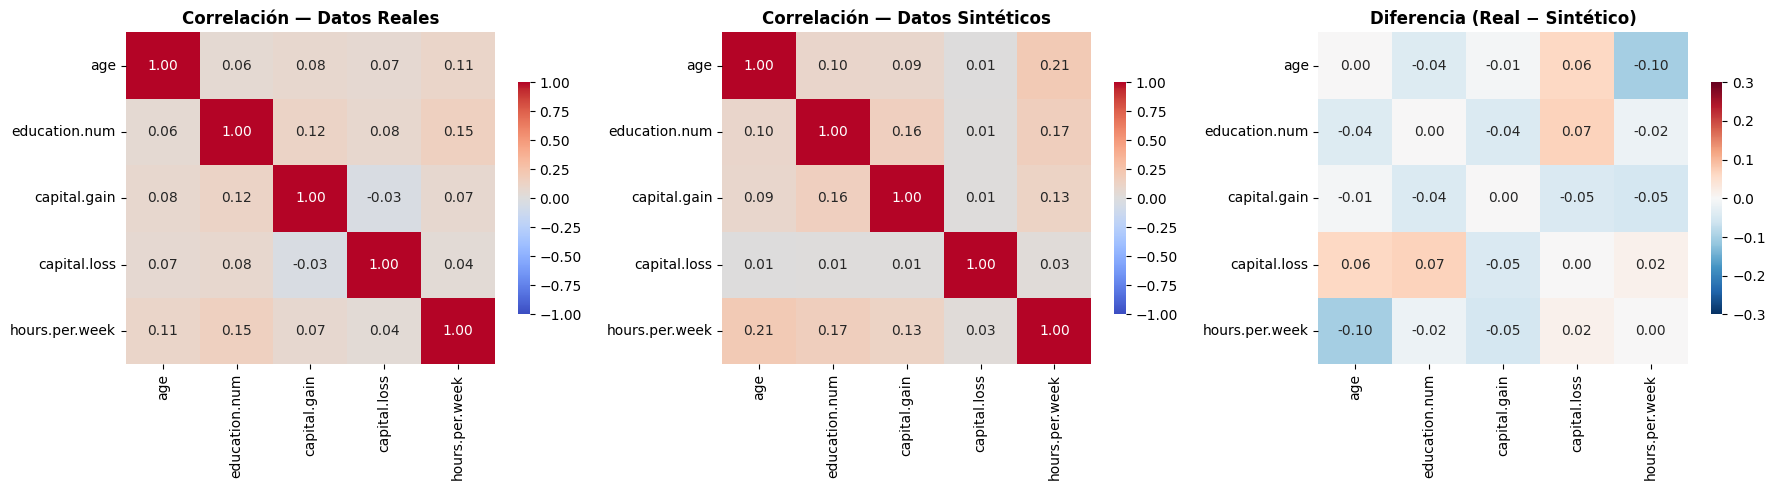

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Matrices de correlación (solo continuas)
corr_real = df_train[continuous_columns].corr()
corr_synthetic = synthetic_data[continuous_columns].corr()

# Diferencia y norma de Frobenius
diff = corr_real - corr_synthetic
frobenius = np.linalg.norm(diff.values, ord='fro')

# Normalizamos: dividimos por la norma de la matriz real para tener un valor relativo
frobenius_relative = frobenius / np.linalg.norm(corr_real.values, ord='fro')

print(f"Norma de Frobenius (absoluta):  {frobenius:.4f}")
print(f"Norma de Frobenius (relativa):  {frobenius_relative:.4f}  ({frobenius_relative*100:.2f}%)")

# Visualización: tres heatmaps lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr_real, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[0], cbar_kws={'shrink': 0.7})
axes[0].set_title('Correlación — Datos Reales', fontsize=12, weight='bold')

sns.heatmap(corr_synthetic, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[1], cbar_kws={'shrink': 0.7})
axes[1].set_title('Correlación — Datos Sintéticos', fontsize=12, weight='bold')

sns.heatmap(diff, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-0.3, vmax=0.3,
            ax=axes[2], cbar_kws={'shrink': 0.7})
axes[2].set_title('Diferencia (Real − Sintético)', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('matriz_correlacion_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ============================================================
# 1. Preparación: separar X (features) e y (target)
# ============================================================
target = 'income'
features_categorical = [c for c in discrete_columns if c != target]
features_continuous = continuous_columns

# Datasets
X_real_train = df_train.drop(columns=[target])
y_real_train = df_train[target]

X_synthetic = synthetic_data.drop(columns=[target])
y_synthetic = synthetic_data[target]

X_holdout = df_holdout.drop(columns=[target])
y_holdout = df_holdout[target]

print(f"Real train:  {X_real_train.shape}")
print(f"Synthetic:   {X_synthetic.shape}")
print(f"Holdout:     {X_holdout.shape}")

# ============================================================
# 2. Pipeline de preprocesamiento (One-Hot para categóricas)
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categorical),
        ('num', 'passthrough', features_continuous)
    ]
)

# ============================================================
# 3. Función auxiliar: entrenar y evaluar
# ============================================================
def evaluar_modelo(X_train, y_train, X_test, y_test, nombre):
    """Entrena un Random Forest y devuelve métricas sobre el test."""
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Convertir y_test a binario para AUC (income: <=50K → 0, >50K → 1)
    y_test_bin = (y_test == '>50K').astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label='>50K')
    auc = roc_auc_score(y_test_bin, y_proba)
    
    print(f"\n--- {nombre} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 (>50K): {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    
    return {'accuracy': acc, 'f1': f1, 'auc': auc}

# ============================================================
# 4. Experimento TSTR vs baseline
# ============================================================
print("=" * 60)
print("EVALUACIÓN DE UTILIDAD PREDICTIVA — TSTR vs BASELINE")
print("=" * 60)

# Baseline: Train Real, Test Real
baseline = evaluar_modelo(
    X_real_train, y_real_train,
    X_holdout, y_holdout,
    "BASELINE: Train Real → Test Real (holdout)"
)

# TSTR: Train Synthetic, Test Real
tstr = evaluar_modelo(
    X_synthetic, y_synthetic,
    X_holdout, y_holdout,
    "TSTR: Train Synthetic → Test Real (holdout)"
)

# ============================================================
# 5. Comparación final
# ============================================================
print("\n" + "=" * 60)
print("COMPARACIÓN — Ratio TSTR / Baseline")
print("=" * 60)
print(f"{'Métrica':<15}{'Baseline':>12}{'TSTR':>12}{'Ratio':>12}{'Pérdida':>12}")
print("-" * 63)
for metrica in ['accuracy', 'f1', 'auc']:
    b = baseline[metrica]
    t = tstr[metrica]
    ratio = t / b
    perdida = (1 - ratio) * 100
    print(f"{metrica:<15}{b:>12.4f}{t:>12.4f}{ratio:>12.4f}{perdida:>11.2f}%")

Real train:  (10000, 13)
Synthetic:   (10000, 13)
Holdout:     (20162, 13)
EVALUACIÓN DE UTILIDAD PREDICTIVA — TSTR vs BASELINE

--- BASELINE: Train Real → Test Real (holdout) ---
Accuracy:  0.8385
F1 (>50K): 0.6622
AUC-ROC:   0.8870

--- TSTR: Train Synthetic → Test Real (holdout) ---
Accuracy:  0.8200
F1 (>50K): 0.6111
AUC-ROC:   0.8673

COMPARACIÓN — Ratio TSTR / Baseline
Métrica            Baseline        TSTR       Ratio     Pérdida
---------------------------------------------------------------
accuracy             0.8385      0.8200      0.9779       2.21%
f1                   0.6622      0.6111      0.9228       7.72%
auc                  0.8870      0.8673      0.9778       2.22%


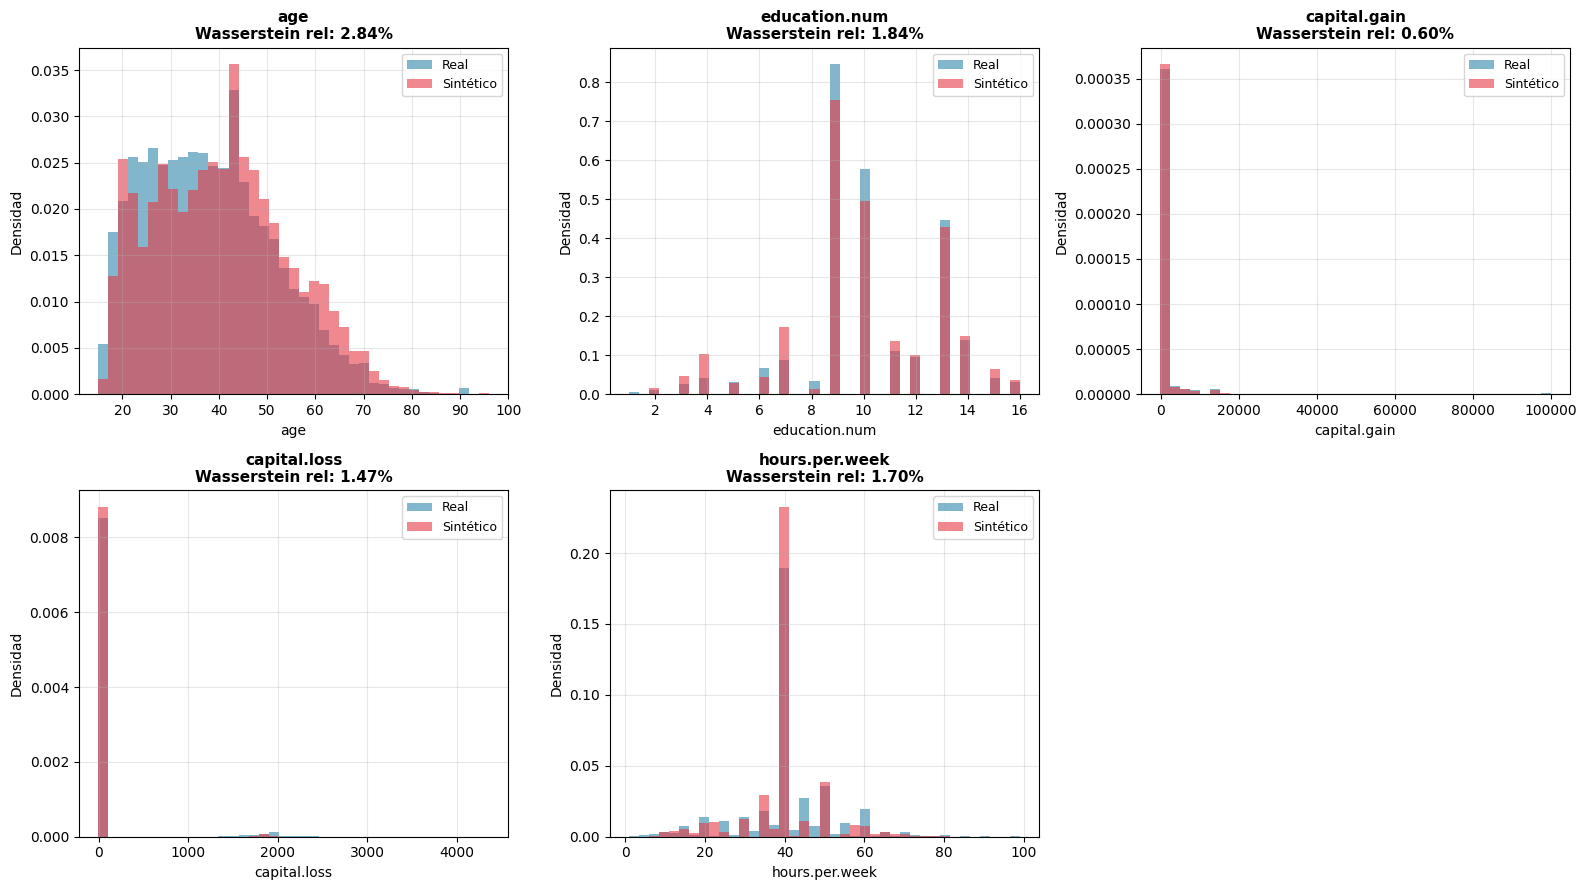

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    ax = axes[i]
    
    real_values = df_train[col].values
    synthetic_values = synthetic_data[col].values
    
    # Bins compartidos para comparación justa
    min_val = min(real_values.min(), synthetic_values.min())
    max_val = max(real_values.max(), synthetic_values.max())
    bins = np.linspace(min_val, max_val, 40)
    
    ax.hist(real_values, bins=bins, alpha=0.6, label='Real', color='#2E86AB', density=True)
    ax.hist(synthetic_values, bins=bins, alpha=0.6, label='Sintético', color='#E63946', density=True)
    
    ax.set_title(f'{col}\nWasserstein rel: {resultados_wasserstein[col] / (max_val - min_val) * 100:.2f}%',
                 fontsize=11, weight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Ocultar el sexto subplot vacío
axes[5].axis('off')

plt.tight_layout()
plt.savefig('histogramas_continuas.png', dpi=150, bbox_inches='tight')
plt.show()

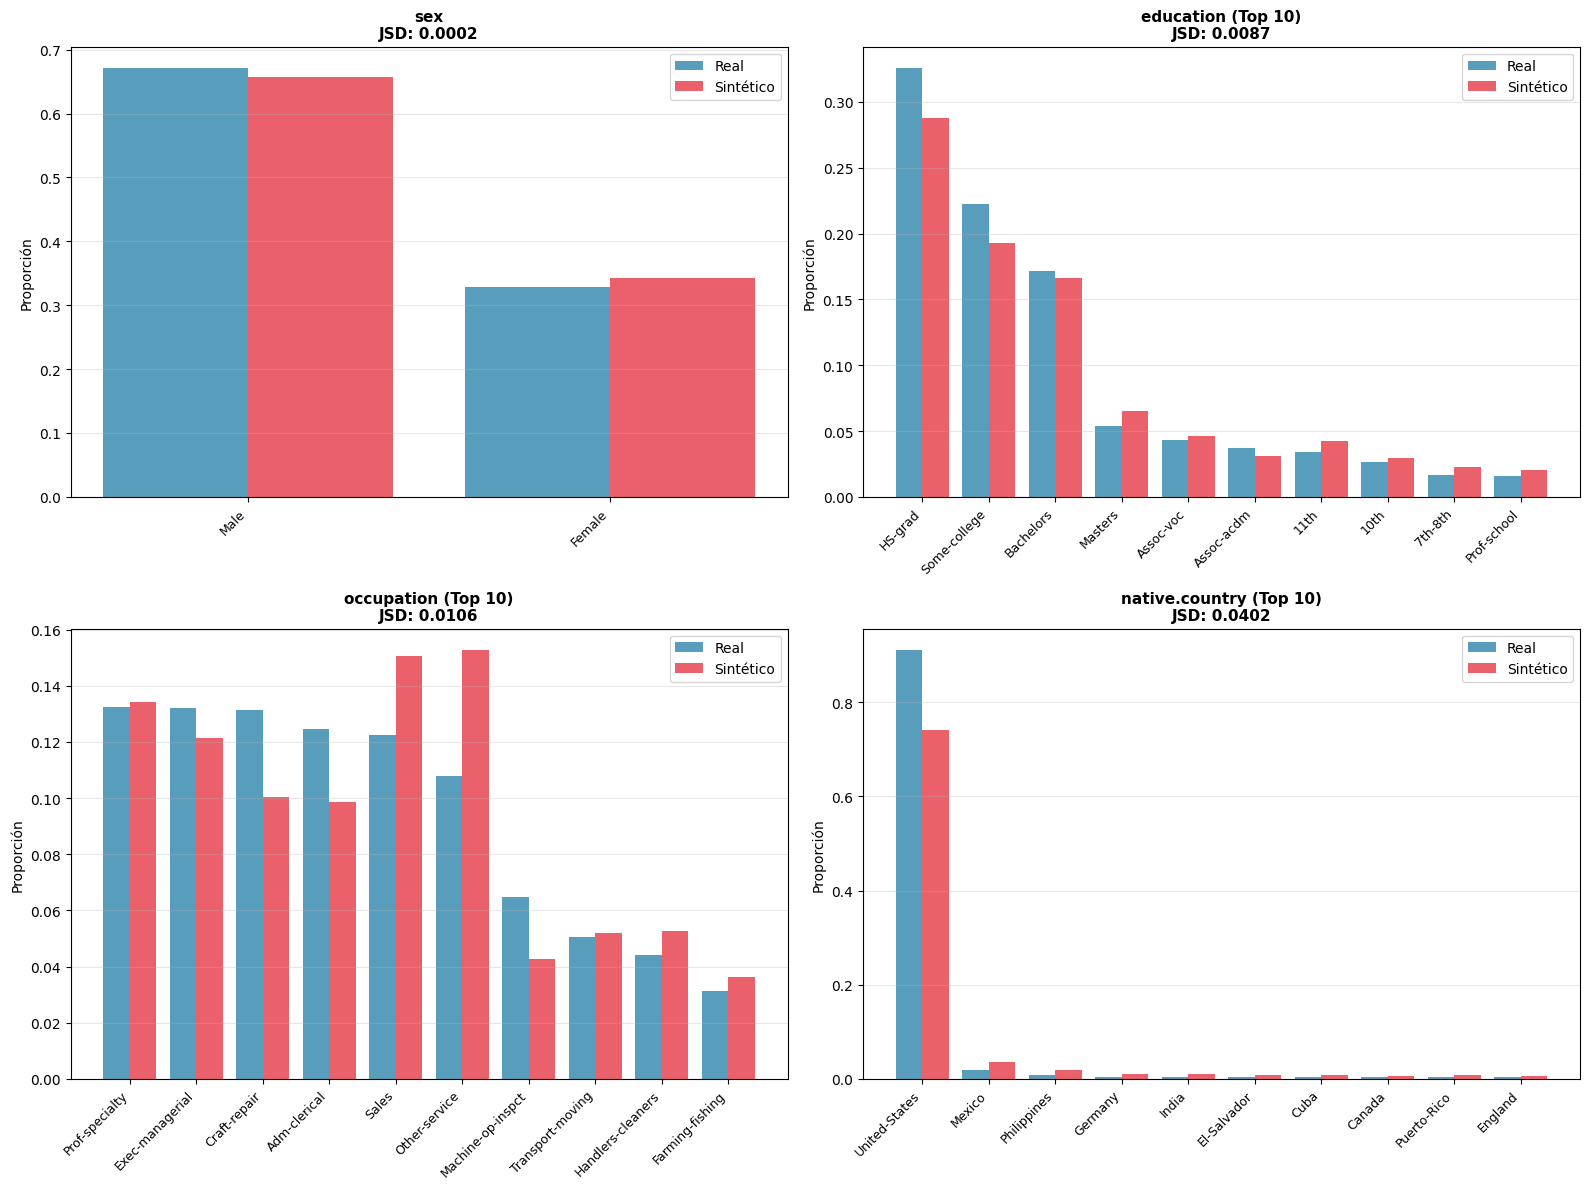

In [28]:
# Seleccionamos 4 categóricas representativas: 1 binaria, 2 cardinalidad media, 1 alta cardinalidad
cats_to_plot = ['sex', 'education', 'occupation', 'native.country']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cats_to_plot):
    ax = axes[i]
    
    real_dist = df_train[col].value_counts(normalize=True).sort_values(ascending=False)
    synthetic_dist = synthetic_data[col].value_counts(normalize=True)
    
    # Para alta cardinalidad mostramos solo top 10
    if df_train[col].nunique() > 10:
        top_categories = real_dist.head(10).index
        real_dist = real_dist.loc[top_categories]
        synthetic_dist = synthetic_dist.reindex(top_categories, fill_value=0)
        title_suffix = ' (Top 10)'
    else:
        synthetic_dist = synthetic_dist.reindex(real_dist.index, fill_value=0)
        title_suffix = ''
    
    x = np.arange(len(real_dist))
    width = 0.4
    
    ax.bar(x - width/2, real_dist.values, width, label='Real', color='#2E86AB', alpha=0.8)
    ax.bar(x + width/2, synthetic_dist.values, width, label='Sintético', color='#E63946', alpha=0.8)
    
    ax.set_title(f'{col}{title_suffix}\nJSD: {resultados_jsd[col]:.4f}',
                 fontsize=11, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(real_dist.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Proporción')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('barras_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
print("\n" + "=" * 60)
print("COMPARACIÓN DE MEDIAS — Variables Continuas")
print("=" * 60)
print(f"{'Variable':<20}{'Media Real':>15}{'Media Sint.':>15}{'Diferencia':>15}")
print("-" * 65)

for col in continuous_columns:
    media_real = df_train[col].mean()
    media_sint = synthetic_data[col].mean()
    dif_pct = abs(media_real - media_sint) / media_real * 100 if media_real != 0 else 0
    print(f"{col:<20}{media_real:>15.2f}{media_sint:>15.2f}{dif_pct:>14.2f}%")


COMPARACIÓN DE MEDIAS — Variables Continuas
Variable                 Media Real    Media Sint.     Diferencia
-----------------------------------------------------------------
age                           38.25          40.53          5.96%
education.num                 10.15          10.01          1.38%
capital.gain                1066.31         479.94         54.99%
capital.loss                  88.85          25.53         71.27%
hours.per.week                40.83          39.89          2.30%
